# 🏥 Laboratório Prático — A Batalha dos Modelos: KNN vs Árvore de Decisão
### Diagnóstico de Câncer de Mama

**Módulo:** Fundamentação em Machine Learning — Semana 11
**Aula:** 3 de 3 (Laboratório Prático)
**Duração total:** 2h30min (150 minutos)
**Pré-requisitos:** Aula 1 (KNN) e Aula 2 (Árvore de Decisão)

---

## 🎯 O Cenário

Vocês fazem parte de uma equipe júnior de Ciência de Dados contratada por um **hospital** para
desenvolver um modelo de apoio ao diagnóstico de câncer de mama. O objetivo é classificar
tumores como **malignos** ou **benignos** a partir de medidas extraídas de exames de imagem.

O hospital pediu que a equipe **compare dois modelos diferentes** — KNN e Árvore de Decisão —
e entregue uma **recomendação justificada** sobre qual modelo é mais adequado para apoiar a
equipe médica, considerando não só a acurácia, mas também:

- O risco de **falsos negativos** (dizer que o tumor é benigno quando na verdade é maligno — o
  erro mais perigoso em um contexto clínico);
- A **interpretabilidade** do modelo para médicos que não são especialistas em ML.

Vocês vão implementar o pipeline completo: carregar os dados, pré-processar, treinar os dois
modelos, compará-los e escrever um pequeno relatório de recomendação para o hospital.

---

## ⚠️ Regras do Laboratório

- Este notebook contém **apenas instruções**. Vocês devem escrever todo o código.
- Sigam a ordem das seções — cada uma se apoia na anterior.
- Fiquem de olho no tempo sugerido em cada etapa (é um guia, não uma regra rígida).
- Se travarem por mais de 5-10 minutos em algo, chamem a mentora.
- Ao final, cada grupo deve ter um notebook rodando do início ao fim + o relatório da
  Parte 6 preenchido.

## ⏱️ Roteiro de Tempo Sugerido

| Etapa | Conteúdo | Tempo |
|---|---|---|
| 0 | Setup do ambiente | 5 min |
| 1 | Exploração dos dados | 15 min |
| 2 | Pré-processamento | 15 min |
| 3 | Modelo 1: KNN | 35 min |
| 4 | Modelo 2: Árvore de Decisão | 35 min |
| 5 | Comparação final entre os modelos | 25 min |
| 6 | Relatório de recomendação para o hospital | 15 min |
| — | Buffer / dúvidas / ajustes finais | 5 min |
| **Total** | | **150 min** |


---
## 🔧 Parte 0 — Setup do Ambiente (~5 min)

Importem todas as bibliotecas que vocês vão precisar ao longo do laboratório. Pensem no que já
usaram nas aulas 1 e 2:

- Manipulação de dados: `pandas`
- Visualização: `matplotlib.pyplot`, `seaborn`
- O dataset de câncer de mama (já vem embutido no scikit-learn) - ´scikit_learn´
- Separação treino/teste
- Padronização/escalonamento de dados
- O classificador KNN
- O classificador de Árvore de Decisão
- Métricas de avaliação: relatório de classificação e matriz de confusão

**Dica:** todas essas ferramentas já foram usadas nas duas aulas anteriores. Revisem seus
notebooks das Aulas 1 e 2 se precisarem relembrar os nomes exatos dos módulos.

In [4]:
# IMPORTANDO AS BIBLIOTECAS NECESSÁRIAS PARA O PROJETO
#Manipulação de dados
import pandas as pd

#vizualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

#dataset
from sklearn.datasets import load_breast_cancer

#separação de dados
from sklearn.model_selection import train_test_split

#Pré processamento de dados
from sklearn.preprocessing import StandardScaler

#modelos de machine learning
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier

#avaliação dos dados
from sklearn.metrics import confusion_matrix, classification_report


---
## 🔍 Parte 1 — Exploração dos Dados (~15 min)

O hospital forneceu um conjunto de dados com medidas extraídas digitalmente de exames de
imagem de tumores de mama (o dataset `load_breast_cancer` do scikit-learn).

**Façam:**

1. Carreguem o dataset e criem um `DataFrame` do pandas com as *features* (`X`) e uma `Series`
   com o alvo (`y`). Lembrem-se: no dataset original, `0 = maligno` e `1 = benigno`.
2. Mostrem as 5 primeiras linhas de `X` e de `y`.
3. Verifiquem quantas *features* (colunas) e quantas amostras (linhas) existem no total.
4. Verifiquem se existem valores ausentes (nulos) nos dados.
5. Analisem o **balanceamento das classes**: quantos casos malignos e quantos benignos existem?
   Isso é relevante para o hospital? Por quê?
6. (Opcional, se der tempo) Façam um gráfico simples (ex: `countplot` do seaborn) mostrando a
   distribuição das classes.

**Perguntas para pensar (anotem a resposta em uma célula de markdown):**
- As classes estão balanceadas ou desbalanceadas? Isso importa no diagnóstico médico?
- Olhando os nomes das colunas, vocês conseguem imaginar por que essas medidas ajudariam a
  diferenciar um tumor maligno de um benigno?

Carregando o conjunto de dados de câncer de mama...
Número de amostras (linhas): 569
Número de features (colunas): 30
Valores nulos no dataframe X: 0
Diagnostico
1    357
0    212
Name: count, dtype: int64


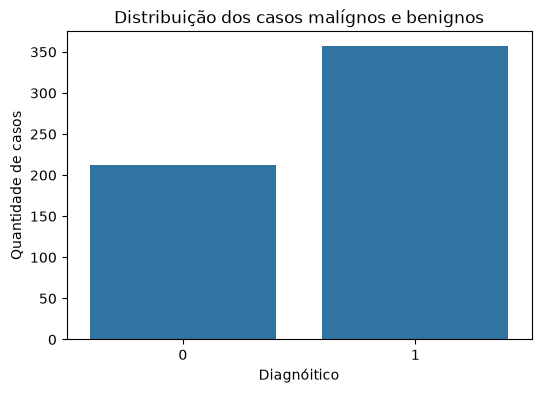

Explorando as primeiras linhas do dataframe X:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [54]:
# Seu código aqui
print("Carregando o conjunto de dados de câncer de mama...")
cancer = load_breast_cancer()

#criando o dataframe X
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)

#criando o dataframe y
y = pd.Series(cancer.target, name="Diagnostico")

#visualizando as primeiras linhas do dataframe X
X.head()

#visualizando as primeiras linhas do dataframe y
y.head()

print("Número de amostras (linhas):", X.shape[0])
print("Número de features (colunas):", X.shape[1])

#somando valores nulos do dataframe X (primeiro soma por coluna e depois soma o total de todas as colunas)
print("Valores nulos no dataframe X:", X.isnull().sum().sum())

#verirficando o balçanceamento dos dados na coluna target
print(y.value_counts())


#gerando um grafico countplot para visualizar a distribuição dos dados na coluna target
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Distribuição dos casos malígnos e benignos")
plt.xlabel("Diagnóitico")
plt.ylabel("Quantidade de casos")
plt.show()

print("Explorando as primeiras linhas do dataframe X:")
display(X.head())

**Respostas (Parte 1):**

As classes possuem um desbalanceamento pequeno. Considerando que o data ser possui ao total 569 amostras. Os casos benignos representam em torno de 62,74% enquanto os maplígnos representam aproximadamente 32,25%. O desbalanceamento dos dados deve ser considerando neste caso, pois a presença dele pode levar a um treinamento errado do modelo e ocasioanr previsões com sérias consequencias, indo desde conxsequencias psicológicas até consequencias médicas em orientar e conduzir casos que afetam diretamente a vida das pessoas. Essa distribuição é relevante porque a acurácia isoladamente pode mascarar erros na identificação dos casos malignos. No contexto hospitalar, falsos negativos são especialmente críticos, portanto será necessário analisar métricas específicas da classe maligna.

Verificando os nomes das colunas é possivel identificar que elas rpesentam caracteristicas físicas dos tumores, estas por sua vez trazem informações sobre a morfologia do tumor, as quais podem estar associadas como sendo benignos ou malígnos.

---
## ⚙️ Parte 2 — Pré-processamento (~15 min)

Antes de treinar qualquer modelo, os dados precisam estar prontos.

**Façam:**

1. Dividam os dados em treino e teste (sugestão: 80% treino / 20% teste). Usem uma divisão
   **estratificada** — pensem em por que isso é especialmente importante neste problema.
2. Fixem uma semente aleatória (`random_state`) para que o experimento seja reprodutível.
3. Apliquem o **escalonamento** (padronização) das features de treino e teste.

**Perguntas para pensar (respondam em markdown):**
- Por que o escalonamento é indispensável para o KNN, mas não é obrigatório para a Árvore de
  Decisão? Relembrem como cada algoritmo funciona internamente (distâncias vs. regras de
  divisão).
- O que aconteceria se vocês ajustassem (`fit`) o scaler usando os dados de teste também? Por
  que isso seria um erro (dica: *data leakage*)?

In [59]:
#dividindo os dados de treino e teste (80% treino e 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42, test_size=0.2, stratify=y)

print(f"Quantidade de amostras de Treino: {X_train.shape[0]}")
print(f"Quantidade de amostras de Teste: {X_test.shape[0]}")

#criando o scaler
scaler = StandardScaler()

#ajustando o scaler aos dados de treino e transformando os dados de treino e teste
X_train_scaled = scaler.fit_transform(X_train)

#ajustando o scaler aos dados de treino e transformando os dados de teste
X_test_scaled = scaler.transform(X_test)

# Visualizar os 5 primeiros registros padronizados do treino
X_train_scaled[:5]



Quantidade de amostras de Treino: 455
Quantidade de amostras de Teste: 114


array([[-1.07200079e+00, -6.58424598e-01, -1.08808010e+00,
        -9.39273639e-01, -1.35939882e-01, -1.00871795e+00,
        -9.68358632e-01, -1.10203235e+00,  2.81062120e-01,
        -1.13231479e-01, -7.04860874e-01, -4.40938351e-01,
        -7.43948977e-01, -6.29804931e-01,  7.48061001e-04,
        -9.91572979e-01, -6.93759567e-01, -9.83284458e-01,
        -5.91579010e-01, -4.28972052e-01, -1.03409427e+00,
        -6.23497432e-01, -1.07077336e+00, -8.76534437e-01,
        -1.69982346e-01, -1.03883630e+00, -1.07899452e+00,
        -1.35052668e+00, -3.52658049e-01, -5.41380026e-01],
       [ 1.74874285e+00,  6.65017334e-02,  1.75115682e+00,
         1.74555856e+00,  1.27446827e+00,  8.42288215e-01,
         1.51985232e+00,  1.99466430e+00, -2.93045055e-01,
        -3.20179716e-01,  1.27567198e-01, -3.81382677e-01,
         9.40746962e-02,  3.17524379e-01,  6.39656015e-01,
         8.73892616e-02,  7.08450758e-01,  1.18215034e+00,
         4.26212305e-01,  7.47970186e-02,  1.22834212e+

**Respostas (Parte 2):**

O KNN crealiza as previsões com base na distância com o vizxinho mais proximo, ou seja a distrancia entre as amostras. Sendo assim, se existir features que possuem valores muito elevados, podem influenciar desproporcionalmente no cálculo das distâncias, mesmo que não tenham necessariamente uma importancia relevante na previsão. Assim, o escalonamento coloca as vairáveis em escalas comparáveis, evitando este problema. Por outro lado, a àrvore de decisão, não utiliza a distância entre as observações, ela ja realiza as divisões dos dados por meio de regras e valores de corte das features, sendo assim o escalonamento não é obrigatório neste modelo.

O scaler deve ser ajustado (fit) exclusivamente com os dados de treino. Caso sejam utilizados também os dados de teste para calcular parâmetros como média e desvio padrão, informações do conjunto de teste estariam sendo incorporadas ao processo de treinamento. Esse problema é conhecido como data leakage. O conjunto de teste deve representar dados novos e desconhecidos pelo modelo, permitindo uma avaliação mais realista de seu desempenho. Por isso, utiliza-se fit_transform() no conjunto de treino e apenas transform() no conjunto de teste.



---
## 🔵 Parte 3 — Modelo 1: KNN (~35 min)

Agora treinem o primeiro modelo.

**Façam:**

1. Treinem um `KNeighborsClassifier` com um valor inicial de `k` (número de vizinhos) à sua
   escolha (ex: k=5) sobre os dados de treino padronizados.
2. Façam as previsões sobre o conjunto de teste.
3. Avaliem o modelo com um relatório de classificação (precision, recall, f1-score) e uma
   matriz de confusão.
4. **Testem pelo menos 3 valores diferentes de `k`** (por exemplo, 3, 5, 7, 9, 15) e comparem os
   resultados. Uma tabela ou um gráfico simples de acurácia (ou recall) por valor de `k` ajuda
   bastante na visualização.
5. Escolham o valor de `k` que vocês considerarem melhor para o contexto do problema e
   justifiquem a escolha.

**Perguntas para pensar (respondam em markdown):**
- No relatório de classificação, qual métrica vocês acham mais importante observar para a
  classe "maligno" neste contexto hospitalar? Por quê?
- O que aconteceu com o desempenho do modelo quando `k` era muito pequeno? E quando era muito
  grande? Isso tem relação com overfitting/underfitting?


Relatório de Classificação:

              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



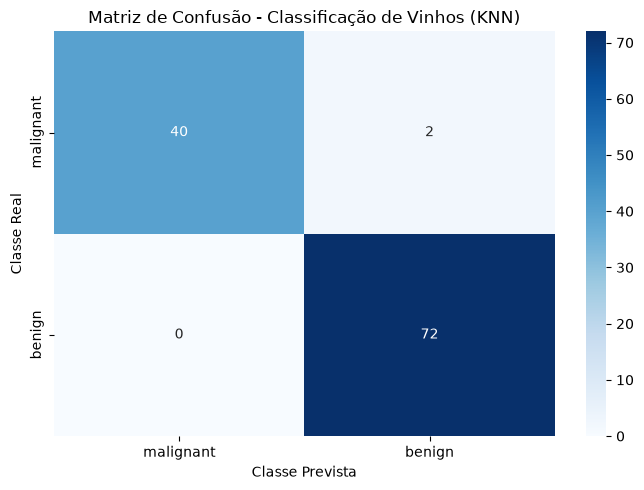

In [85]:
#Treinando um modelo KNN (K-Nearest Neighbors) com os dados de treino padronizados
#criando o modelo KNN com 5 vizinhos
knn = KNeighborsClassifier(n_neighbors=3)

#trinando o modelo KNN com os dados de treino padronizados
knn.fit(X_train_scaled, y_train)

#testando o modelo KNN com os dados de teste padronizados
y_pred = knn.predict(X_test_scaled)

# Exibir o relatório de métricas
print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

# Calcular a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Plotar gráfico de calor (Heatmap)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)

plt.title('Matriz de Confusão - Classificação de Vinhos (KNN)')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()


**Respostas (Parte 3):**

O valor mai adequado a ser escolhido seria oque apresentasse o melhor valor de recall, pois essa métrica responmde: De quantos tumores malignos que existem no teste, quando o modelo conseguiu acertar? Pelos resultados o valor de k=3 foi o que apresentou o valor de 0,95, ou seja 95% de acerto em identificar um tumor maligno, os outros valores de 5 até 15 este valor ficou em 0,93. Além disso na mtriz de consuão para este valor de k=3, temos que somente 2 tumores que realmente eram malignos foram classificados como benignos.

Para valores de k muito pequenois o modelo perdeu eficiencia, pois como ele depende de muitos pocuso vizinhos, se for um caso atípico ou um ruido, a clkassificação ja ocorre somente com este dados.

---
## 🌳 Parte 4 — Modelo 2: Árvore de Decisão (~35 min)

Agora treinem o segundo modelo, para comparar com o KNN.

**Façam:**

1. Treinem um `DecisionTreeClassifier` com uma profundidade máxima (`max_depth`) inicial à sua
   escolha (ex: 3 ou 4) sobre os dados de treino.
2. Façam as previsões sobre o conjunto de teste.
3. Avaliem o modelo com relatório de classificação e matriz de confusão.
4. **Testem pelo menos 3 valores diferentes de `max_depth`** (por exemplo, 2, 4, 6, None/sem
   limite) e comparem os resultados.
5. Para cada profundidade testada, comparem a acurácia no **treino** com a acurácia no
   **teste**. O que isso revela sobre overfitting?
6. Escolham a profundidade que vocês considerarem melhor e justifiquem.
7. (Opcional, se der tempo) Visualizem a árvore treinada (`plot_tree`) e/ou a importância das
   features (`feature_importances_`) — quais medidas do exame o modelo considerou mais
   relevantes para o diagnóstico?

**Perguntas para pensar (respondam em markdown):**
- Uma árvore sem limite de profundidade teve desempenho melhor ou pior no teste do que uma
  árvore mais rasa? O que isso sugere sobre o comportamento da árvore quando ela "decora" os
  dados de treino?
- Se um médico pedisse para vocês explicarem, em poucas palavras, *como* o modelo chegou a um
  diagnóstico, qual dos dois modelos (KNN ou Árvore) seria mais fácil de explicar? Por quê?

**🌟 Desafio bônus (se sobrar tempo):** testem outros hiperparâmetros da árvore, como
`min_samples_leaf` ou `criterion` (gini vs entropy), e vejam se conseguem melhorar o recall da
classe maligna.

              precision    recall  f1-score   support

   malignant       0.80      0.95      0.87        42
      benign       0.97      0.86      0.91        72

    accuracy                           0.89       114
   macro avg       0.88      0.91      0.89       114
weighted avg       0.91      0.89      0.90       114



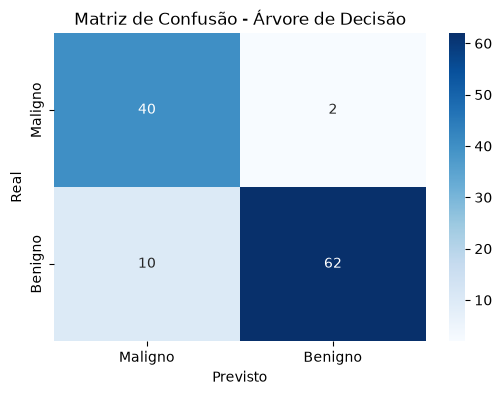

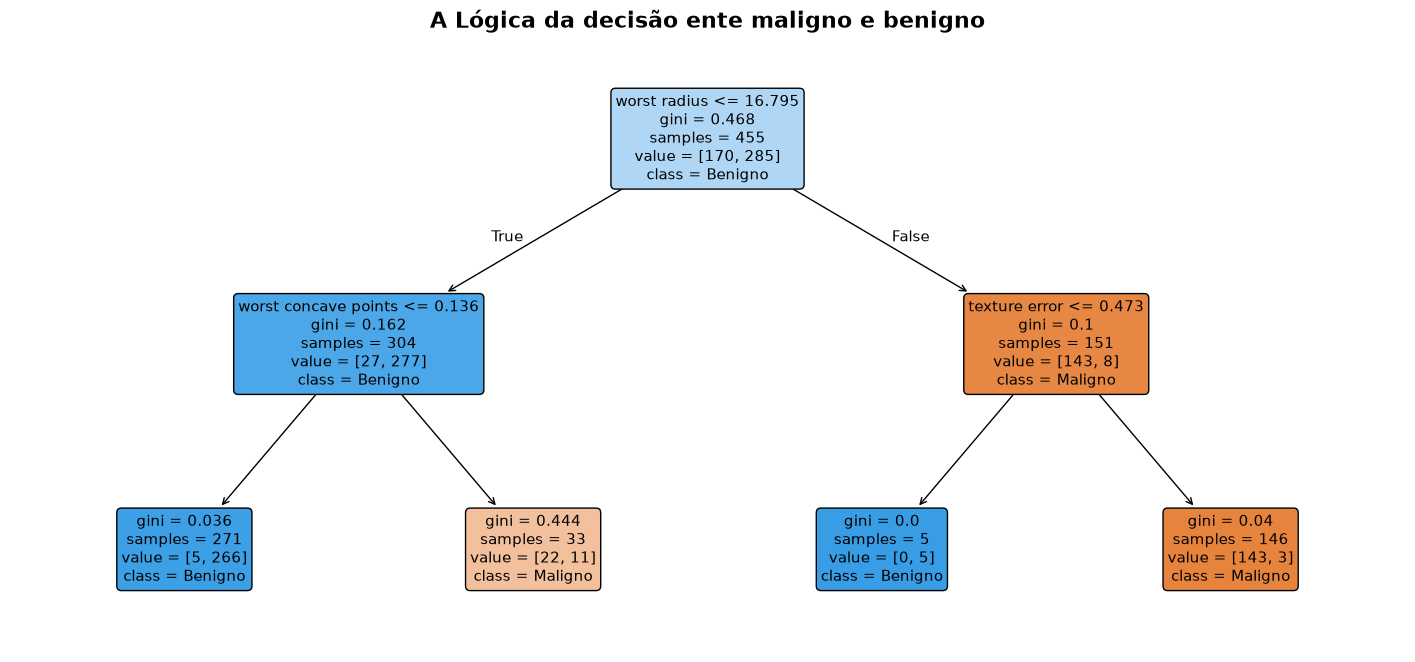

In [100]:
#criando o modelo
modelo_tree = DecisionTreeClassifier(max_depth=2,random_state=42)

#treinando o modelo
modelo_tree.fit(X_train, y_train)

#testando o modelo
y_pred_tree = modelo_tree.predict(X_test)

print(classification_report(
    y_test,
    y_pred_tree,
    target_names=["malignant", "benign"]
))

cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Maligno", "Benigno"],
    yticklabels=["Maligno", "Benigno"]
)

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Árvore de Decisão")

plt.show()

#plotando a arvore de decisão
plt.figure(figsize=(18, 8))
plot_tree(
    modelo_tree,
    feature_names=X.columns,
    class_names=['Maligno', 'Benigno'],
    filled=True,         # Colore as caixinhas (laranja para óbitos, azul para sobreviventes)
    rounded=True,
    fontsize=11
)
plt.title("A Lógica da decisão ente maligno e benigno", fontsize=16, fontweight='bold')
plt.show()

**Respostas (Parte 4):**

A árvore sem limite de profundidade apresentou desempenho pior no conjunto de teste do que uma árvore mais rasa. Ela atingiu 100% de acurácia no treino, mas apenas cerca de 91,2% no teste, enquanto a árvore com max_depth=4 apresentou aproximadamente 93,9% de acurácia no teste. Isso indica overfitting, pois a árvore sem limite se ajustou excessivamente aos dados de treinamento, aprendendo também particularidades e ruídos que não se repetem necessariamente em novos dados. Dessa forma, apesar de "decorar" muito bem o conjunto de treino, sua capacidade de generalização diminuiu.

A Árvore de Decisão seria mais fácil de explicar para um médico. Isso ocorre porque sua previsão pode ser acompanhada por uma sequência de regras, como comparar determinadas características do exame com valores de corte até chegar à classificação final. O KNN, por outro lado, classifica um novo caso com base na distância em relação aos casos mais próximos, considerando várias características padronizadas, o que torna a explicação de uma previsão individual menos direta. Portanto, a Árvore de Decisão possui maior vantagem em termos de interpretabilidade.

---
## ⚖️ Parte 5 — Comparação Final entre os Modelos (~25 min)

Com os dois modelos "finais" escolhidos (o melhor `k` do KNN e a melhor `max_depth` da Árvore),
é hora de colocá-los lado a lado.

**Façam:**

1. Gerem as **matrizes de confusão dos dois modelos lado a lado** (um gráfico ao lado do
   outro), com títulos e eixos claros indicando o que representa cada célula.
2. Montem uma **tabela comparativa** (pode ser um DataFrame simples) com, no mínimo:
   accuracy, precision, recall e f1-score de cada modelo — com destaque para os valores da
   classe "maligno".
3. Identifiquem, para cada modelo, **quantos falsos negativos** ele cometeu no conjunto de
   teste (tumores malignos classificados como benignos). Esse número é crítico no contexto
   hospitalar — expliquem por quê em uma célula de markdown.

**Perguntas para pensar (respondam em markdown):**
- Qual modelo teve o menor número de falsos negativos?
- Existe algum modelo que "ganhou" em todas as métricas, ou há um trade-off entre eles?

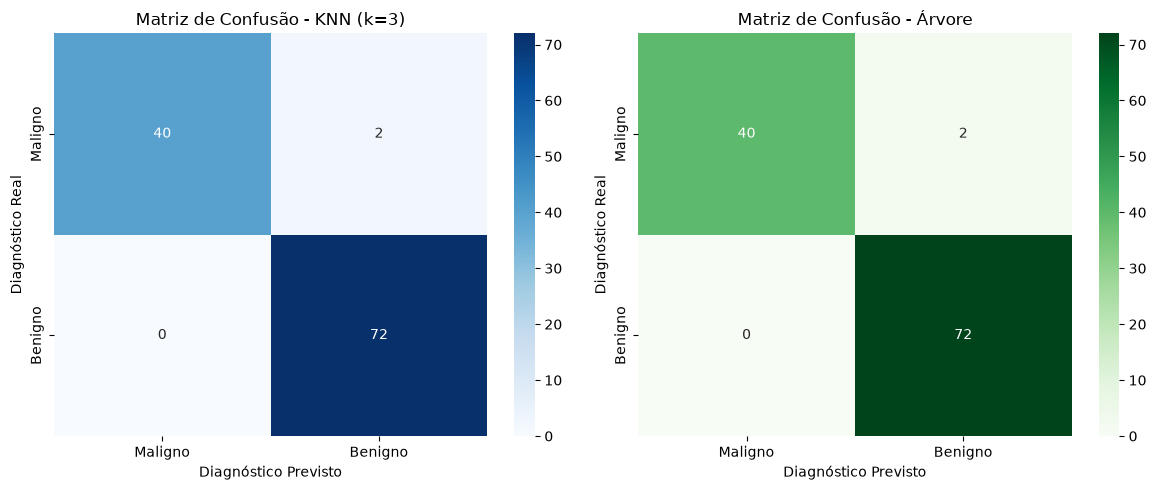

,Modelo,Accuracy,Precision Maligno,Recall Maligno,F1-score Maligno
0,KNN (k=3),0.98,1.0,0.95,0.98
1,Árvore (max_depth=2),0.89,0.8,0.95,0.87


In [104]:
# Seu código aqui
cm_knn = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

cm_tree = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Matriz KNN
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Maligno", "Benigno"],
    yticklabels=["Maligno", "Benigno"],
    ax=axes[0]
)

axes[0].set_title("Matriz de Confusão - KNN (k=3)")
axes[0].set_xlabel("Diagnóstico Previsto")
axes[0].set_ylabel("Diagnóstico Real")


# Matriz Árvore
sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Maligno", "Benigno"],
    yticklabels=["Maligno", "Benigno"],
    ax=axes[1]
)

axes[1].set_title("Matriz de Confusão - Árvore")
axes[1].set_xlabel("Diagnóstico Previsto")
axes[1].set_ylabel("Diagnóstico Real")


plt.tight_layout()
plt.show()


comparacao_modelos = pd.DataFrame({
    "Modelo": [
        "KNN (k=3)",
        "Árvore (max_depth=2)"
    ],

    "Accuracy": [
        0.98,
        0.89
    ],

    "Precision Maligno": [
        1.00,
        0.80
    ],

    "Recall Maligno": [
        0.95,
        0.95
    ],

    "F1-score Maligno": [
        0.98,
        0.87
    ]
})

comparacao_modelos

**Respostas (Parte 5):**

Ambos os modelos apresentaram o memso numero de falsos positivos, sneod que apresentaram 02 falsos positivos. o KNN está claramente vencendo a árvore em desempenho, enquanto a árvore vence em interpretabilidade.

---
## 📋 Parte 6 — Relatório de Recomendação para o Hospital (~15 min)

Chegou a hora de traduzir o trabalho técnico em uma recomendação de negócio/clínica. Escrevam,
na célula de markdown abaixo, um pequeno relatório (não precisa ser longo — 1 a 2 parágrafos
por pergunta) respondendo:

1. **Qual dos dois modelos vocês recomendam para o hospital usar como apoio ao diagnóstico, e
   por quê?** Justifiquem com base nas métricas observadas (especialmente o recall da classe
   maligna) e não apenas na acurácia geral.
2. **Quais são os riscos de cada modelo** neste contexto clínico específico (pensem em falsos
   negativos vs falsos positivos)?
3. **Interpretabilidade:** qual modelo seria mais fácil de "explicar" para a equipe médica, e
   isso importa na decisão final?
4. **Limitações do estudo:** o que vocês apontariam como limitação deste experimento para o
   hospital (ex: tamanho da amostra, necessidade de validação com mais dados, necessidade de
   validação cruzada, um modelo de ML nunca deve substituir o diagnóstico médico, etc.)?
5. **Próximos passos:** se a equipe tivesse mais tempo, o que vocês testariam a seguir (outros
   algoritmos, ajuste fino mais completo, mais dados, outras métricas)?

> ⚠️ Lembrete importante para o relatório: um modelo de Machine Learning em um contexto médico
> é uma ferramenta de **apoio à decisão**, nunca um substituto do julgamento clínico do
> médico.

### ✍️ Relatório

**Nomes:** Felipe Antonio Cassini

**1. Recomendação:**

Recomendamos o KNN com k=3 como modelo de apoio ao diagnóstico. Ele apresentou cerca de 98% de acurácia, recall de aproximadamente 95% para tumores malignos e apenas 2 falsos negativos. A Árvore de Decisão com max_depth=2 também apresentou 2 falsos negativos e recall semelhante, porém teve acurácia geral menor, próxima de 89%. Considerando principalmente a capacidade de identificar casos malignos sem aumentar excessivamente os demais erros, o KNN apresentou o melhor equilíbrio entre os modelos avaliados.

**2. Riscos de cada modelo:**
O principal risco clínico é o falso negativo, quando um tumor maligno é classificado como benigno, podendo atrasar a investigação e o tratamento. Ambos os modelos apresentaram 2 casos desse tipo na configuração escolhida. A Árvore de Decisão, entretanto, produziu mais falsos positivos, classificando casos benignos como malignos, o que pode gerar exames adicionais, ansiedade e custos desnecessários. Por isso, embora falsos positivos também sejam relevantes, falsos negativos devem receber maior atenção neste contexto.

**3. Interpretabilidade:**
A Árvore de Decisão é mais fácil de explicar à equipe médica, pois permite acompanhar regras e valores de corte das características do exame até chegar à classificação. O KNN possui menor interpretabilidade individual, pois sua decisão depende da distância entre o paciente analisado e seus vizinhos mais próximos. Apesar dessa vantagem da árvore, o melhor desempenho geral do KNN justifica sua recomendação como ferramenta de apoio, mantendo a interpretação dos resultados sob responsabilidade da equipe clínica.

**4. Limitações do estudo:**
O estudo utilizou apenas 569 amostras e uma única divisão entre treino e teste, portanto os resultados podem variar com outros pacientes ou outras divisões dos dados. Seriam necessárias validação cruzada, conjuntos de dados maiores e, principalmente, validação com dados clínicos independentes antes de qualquer uso real. Além disso, um modelo de Machine Learning deve atuar somente como apoio à decisão médica, nunca como substituto do diagnóstico e do julgamento clínico profissional.

**5. Próximos passos:**
Como próximos passos, testaríamos outros algoritmos. Também avaliaríamos métricas como sensibilidade, especificidade e curva ROC, com atenção especial à redução dos falsos negativos. Por fim, seria importante validar o modelo em uma base maior e independente, representativa da população atendida pelo hospital.

---
## ✅ Critérios de Entrega

Ao final das 2h30min, deverá ser entregue este notebook com:

- [ ] Todas as células de código executadas sem erro, do início ao fim;
- [ ] KNN treinado, testado com múltiplos valores de `k`, e avaliado;
- [ ] Árvore de Decisão treinada, testada com múltiplas profundidades, e avaliada;
- [ ] Matrizes de confusão comparativas dos dois modelos;
- [ ] Tabela comparativa de métricas;
- [ ] Todas as perguntas "para pensar" respondidas nas células de markdown correspondentes;
- [ ] Relatório final (Parte 6) preenchido.
